In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("/content/E-commerce_reverse_logistics.xlsx")

In [ ]:
df.head()

,return_id,order_id,customer_id,product_id,product_name,sku,return_request_date,return_approval_date,Approval_delay,return_received_date,...,warehouse_state,warehouse_country,inspected_by,inspection_date.1,inspection_cost,processing_cost,refurbishment_cost,disposal_cost,recovery_value,reverse_logistics_cost
0,RET00121,ORD100121,CUST0306,PRD60197,Men's Casual Shoes Brown Size 10,SHO-MN-BR10,2025-07-28,2025-08-01,4,2025-08-03,...,KA,India,EMP03,2025-08-03,61.54,103.64,192.65,24.92,19929.75,455.95
1,RET00122,ORD100122,CUST0497,PROD0044,Premium Bath Towel White,NaN,2025-12-06,2025-12-08,2,2025-12-10,...,TS,India,EMP02,2025-12-11,35.75,82.61,134.46,38.98,435.21,415.64
2,RET00123,ORD100123,CUST0224,PROD0005,Digital Kitchen Scale Stainless Steel,DGS-STL-SS,2025-11-20,2025-11-23,3,2025-11-27,...,DL,India,EMP03,2025-11-28,35.39,88.73,145.47,134.95,10363.47,388.75
3,RET00124,ORD100124,CUST0225,PRD60106,Wireless Earbuds Charging Case White,EARB-WH-CASE,2025-05-05,2025-05-05,0,2025-05-07,...,MH,India,EMP03,2025-05-07,57.53,99.39,68.11,82.99,921.33,382.55
4,RET00125,ORD100125,CUST0298,PROD0045,Wireless Gaming Mouse RGB Black,GMOUSE-RGB-BLK,2025-09-21,2025-09-26,5,2025-10-04,...,TS,India,EMP01,2025-10-05,43.80,56.06,157.92,32.81,240.53,426.40


In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
return_id,0
order_id,0
customer_id,0
product_id,0
product_name,0
sku,57
return_request_date,0
return_approval_date,0
Approval_delay,0
return_received_date,0


In [ ]:
df = df.dropna(subset=['sku'])
print(f"DataFrame shape after dropping rows with missing 'sku': {df.shape}")

DataFrame shape after dropping rows with missing 'sku': (923, 37)


### Visualizing Outliers with Box Plots

I will now generate box plots for all numerical columns to visually identify potential outliers. Outliers can skew analyses and models, so understanding their presence is a crucial step in data cleaning and preparation.

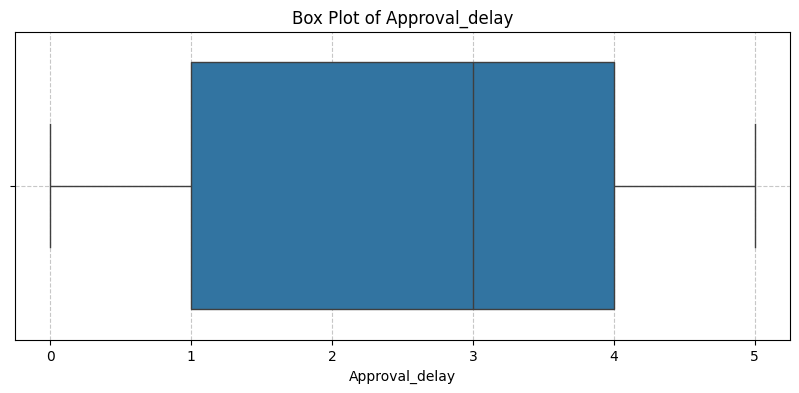

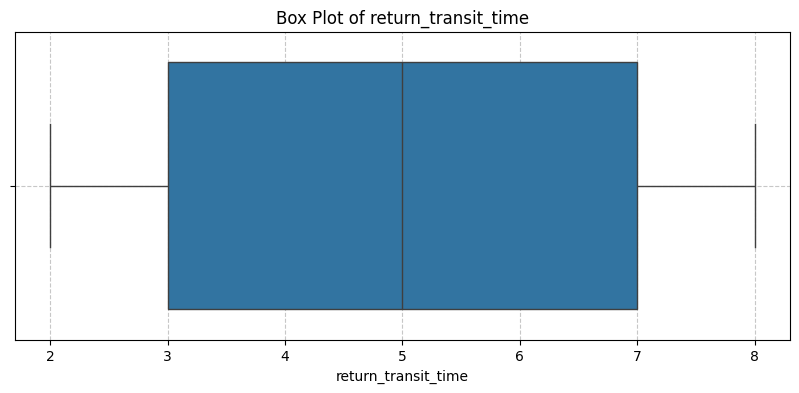

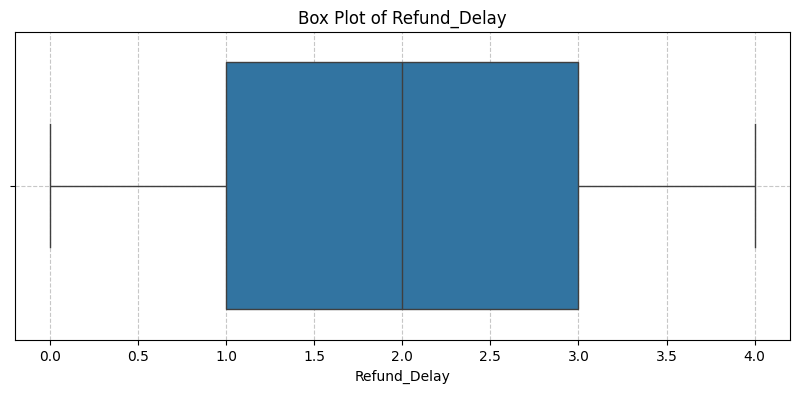

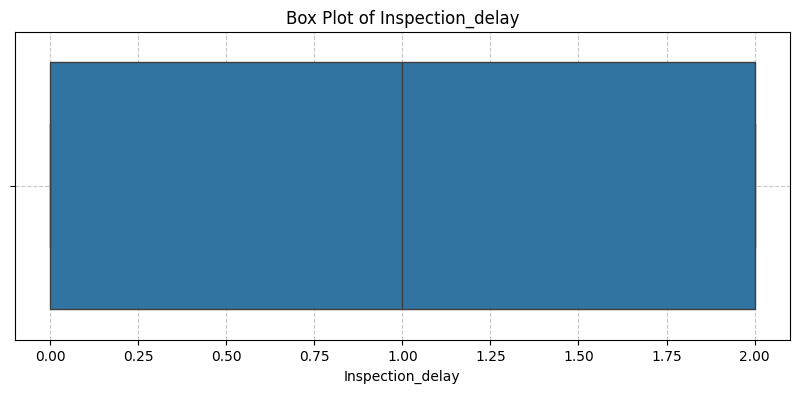

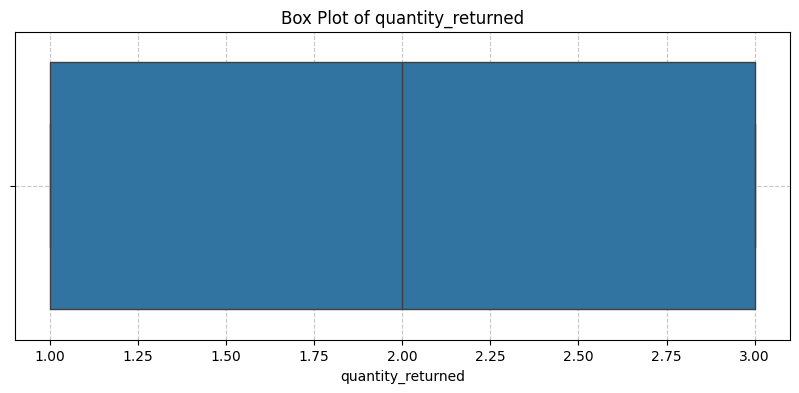

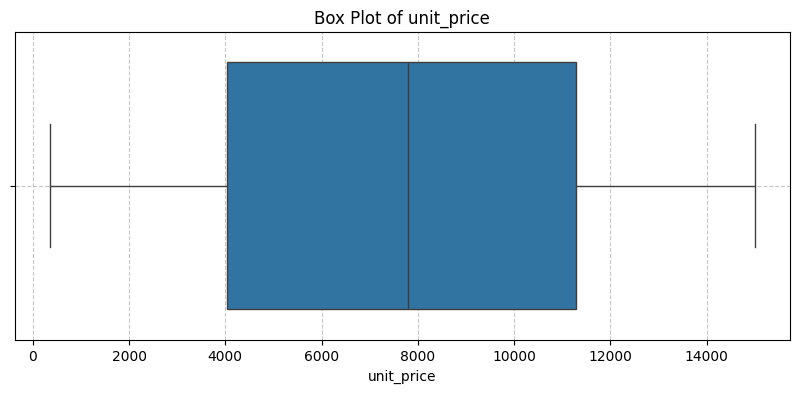

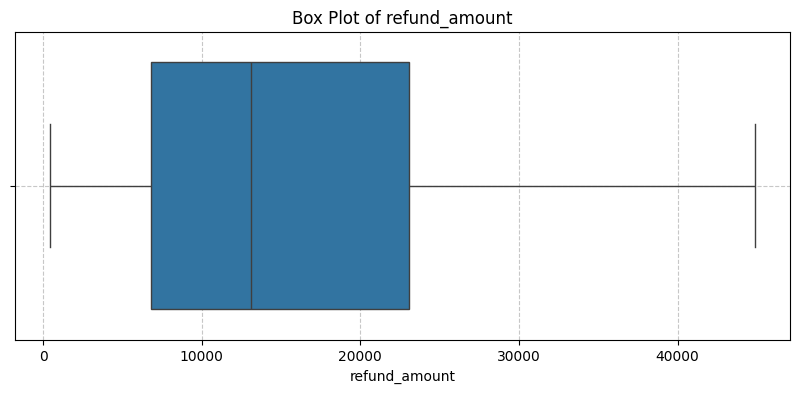

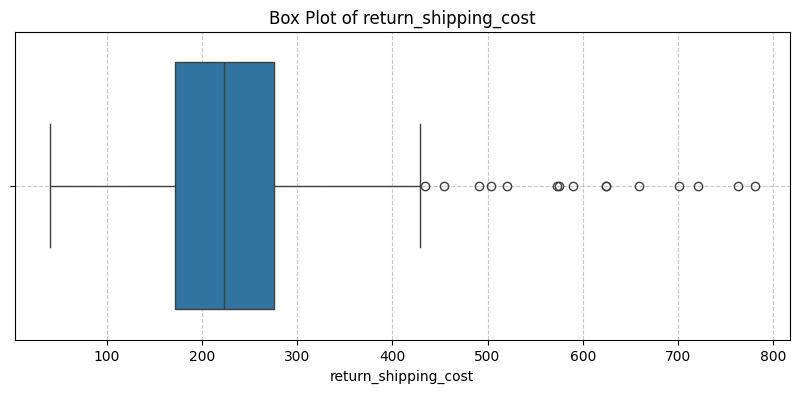

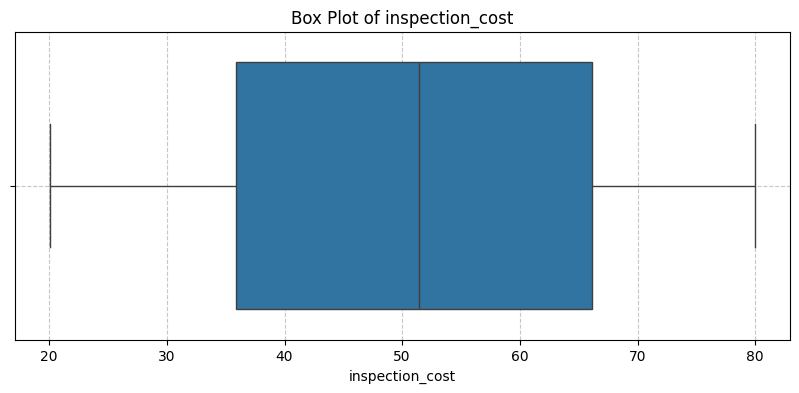

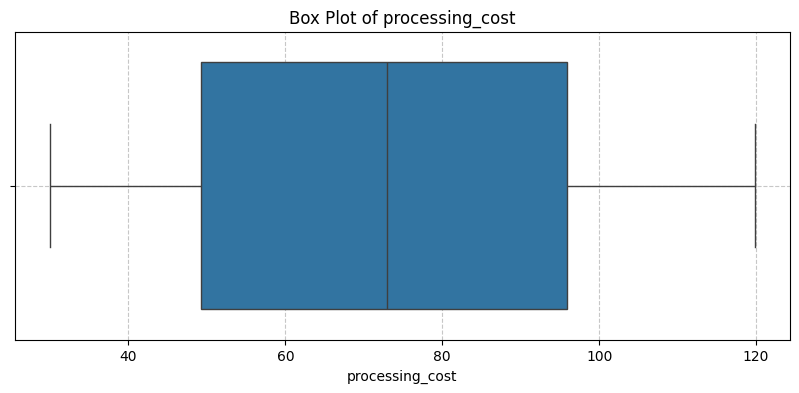

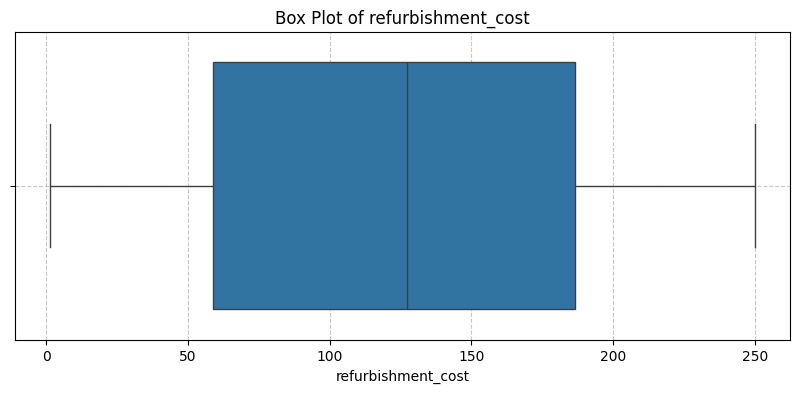

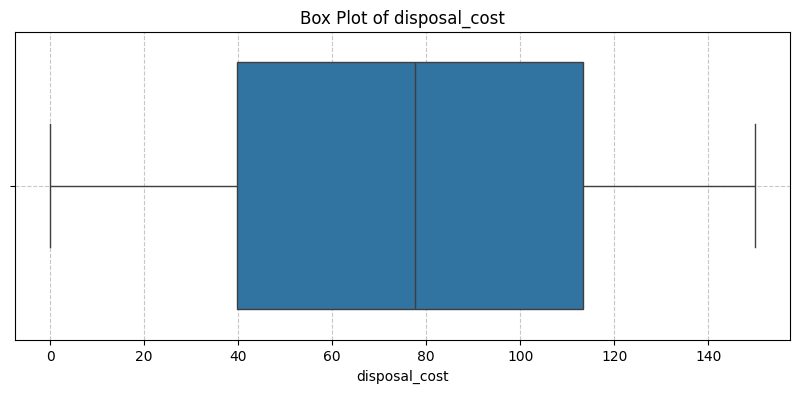

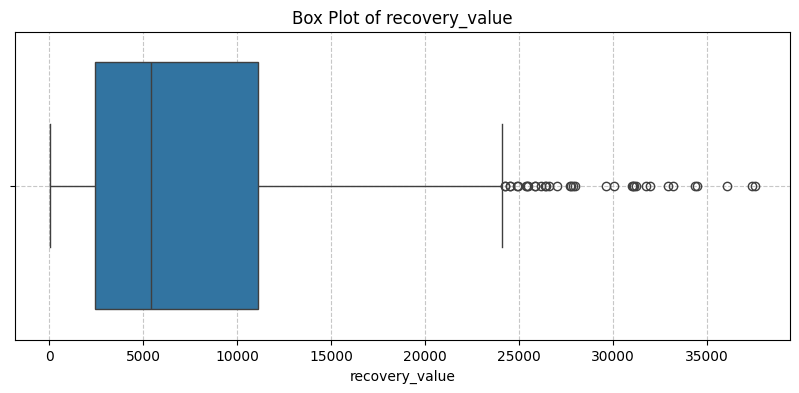

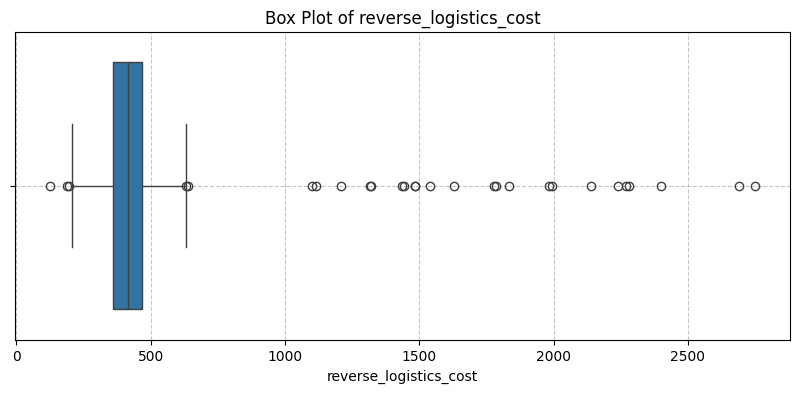

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for box plots
numerical_cols = df.select_dtypes(include=np.number).columns

# Exclude 'return_id', 'order_id', 'customer_id', 'product_id', and 'Unnamed: 20' if they are numerical but act as identifiers
# Note: Assuming these are identifiers and not suitable for box plots even if numerical.
identifier_cols = ['return_id', 'order_id', 'customer_id', 'product_id', 'Unnamed: 20']
numerical_cols = [col for col in numerical_cols if col not in identifier_cols]


# Create box plots for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Outlier Treatment using IQR

I will now apply the Interquartile Range (IQR) method to treat outliers in the numerical columns. This involves identifying values that fall outside the calculated upper and lower bounds (Q1 - 1.5 * IQR and Q3 + 1.5 * IQR) and capping them at these bounds to reduce their extreme influence.

In [ ]:
# Re-using numerical_cols from the previous step
# Exclude 'return_id', 'order_id', 'customer_id', 'product_id' if they are numerical but act as identifiers
identifier_cols = ['return_id', 'order_id', 'customer_id', 'product_id']
numerical_cols = [col for col in df.select_dtypes(include=np.number).columns if col not in identifier_cols]

# Dictionary to store the number of outliers treated per column
outliers_treated_count = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    num_outliers_before = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    # Cap the outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    # Count outliers after capping (should be 0 if all are capped)
    num_outliers_after = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    if num_outliers_before > 0:
        outliers_treated_count[col] = num_outliers_before

print("Number of outliers treated (capped) per numerical column:")
if outliers_treated_count:
    for col, count in outliers_treated_count.items():
        print(f"- {col}: {count} outliers")
else:
    print("No outliers were treated in the selected numerical columns based on the IQR method.")

print("\nDescriptive statistics after outlier treatment:")
display(df[numerical_cols].describe())

Number of outliers treated (capped) per numerical column:
- return_shipping_cost: 15 outliers
- recovery_value: 35 outliers
- reverse_logistics_cost: 28 outliers

Descriptive statistics after outlier treatment:


,Approval_delay,return_transit_time,Refund_Delay,Inspection_delay,quantity_returned,unit_price,refund_amount,Unnamed: 20,return_shipping_cost,inspection_cost,processing_cost,refurbishment_cost,disposal_cost,recovery_value,reverse_logistics_cost
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,0.0,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,2.478873,5.097508,1.993499,1.042254,2.027086,7700.683640,15665.810401,NaN,225.509266,50.740986,73.564117,124.180401,76.218667,7589.969567,417.364951
std,1.706927,1.964220,1.394893,0.830122,0.794724,4194.145668,11099.271697,NaN,76.321810,17.218290,26.279175,72.578568,42.895519,6532.081350,84.504280
min,0.000000,2.000000,0.000000,0.000000,1.000000,359.000000,443.000000,NaN,40.590000,20.080000,30.010000,1.290000,0.010000,51.860000,195.445000
25%,1.000000,3.000000,1.000000,0.000000,1.000000,4044.000000,6778.500000,NaN,172.170000,35.920000,49.285000,58.700000,39.800000,2438.180000,359.185000
50%,3.000000,5.000000,2.000000,1.000000,2.000000,7787.000000,13110.000000,NaN,222.810000,51.430000,73.000000,127.320000,77.560000,5444.320000,415.590000
75%,4.000000,7.000000,3.000000,2.000000,3.000000,11290.500000,23089.000000,NaN,275.225000,66.120000,95.945000,186.630000,113.290000,11137.420000,468.345000
max,5.000000,8.000000,4.000000,2.000000,3.000000,15000.000000,44859.000000,NaN,429.807500,79.950000,119.810000,249.940000,149.830000,24186.280000,632.085000


### Histograms of Return Shipping Cost and Quantity Returned

I will now create histograms for `return_shipping_cost` and `quantity_returned` to visualize their distributions. Histograms are useful for understanding the underlying frequency distribution of a set of continuous data.

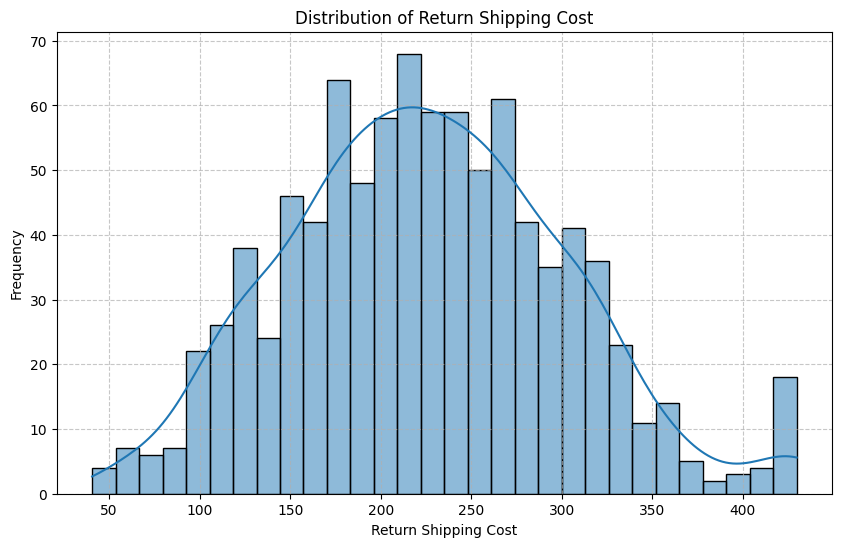

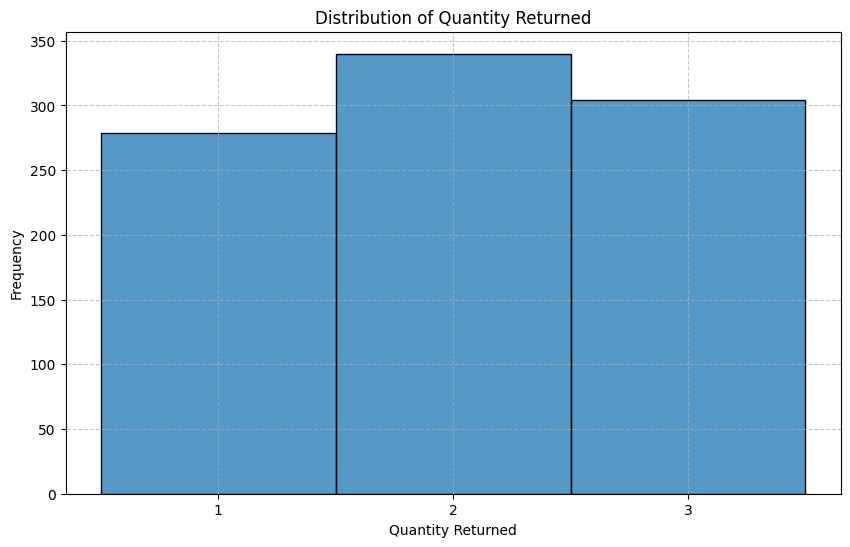

In [ ]:
# Histogram for 'return_shipping_cost'
plt.figure(figsize=(10, 6))
sns.histplot(df['return_shipping_cost'], bins=30, kde=True)
plt.title('Distribution of Return Shipping Cost')
plt.xlabel('Return Shipping Cost')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Histogram for 'quantity_returned'
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_returned'], bins=np.arange(df['quantity_returned'].min(), df['quantity_returned'].max() + 2), kde=False, discrete=True)
plt.title('Distribution of Quantity Returned')
plt.xlabel('Quantity Returned')
plt.ylabel('Frequency')
plt.xticks(np.arange(df['quantity_returned'].min(), df['quantity_returned'].max() + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
columns_to_remove = [
    'reverse_logistics_cost',
    'inspection_cost',
    'processing_cost',
    'refurbishment_cost',
    'disposal_cost',
    'recovery_value'
]

df = df.drop(columns=columns_to_remove)

display(df.head())

,return_id,order_id,customer_id,product_id,product_name,sku,return_request_date,return_approval_date,Approval_delay,return_received_date,...,disposition_outcome,return_shipping_carrier,return_tracking_number,return_shipping_cost,warehouse_id,warehouse_city,warehouse_state,warehouse_country,inspected_by,inspection_date.1
0,RET00121,ORD100121,CUST0306,PRD60197,Men's Casual Shoes Brown Size 10,SHO-MN-BR10,2025-07-28,2025-08-01,4.0,2025-08-03,...,Refurbished,Xpressbees,TRK2573418961,244.3600,WH1,Mumbai,KA,India,EMP03,2025-08-03
2,RET00123,ORD100123,CUST0224,PROD0005,Digital Kitchen Scale Stainless Steel,DGS-STL-SS,2025-11-20,2025-11-23,3.0,2025-11-27,...,Restocked,Xpressbees,TRK3895719209,429.8075,WH4,Mumbai,DL,India,EMP03,2025-11-28
3,RET00124,ORD100124,CUST0225,PRD60106,Wireless Earbuds Charging Case White,EARB-WH-CASE,2025-05-05,2025-05-05,0.0,2025-05-07,...,Restocked,Blue Dart,TRK6584061968,204.6700,WH4,Delhi,MH,India,EMP03,2025-05-07
4,RET00125,ORD100125,CUST0298,PROD0045,Wireless Gaming Mouse RGB Black,GMOUSE-RGB-BLK,2025-09-21,2025-09-26,5.0,2025-10-04,...,Refurbished,Blue Dart,TRK9361005642,219.5100,WH1,Delhi,TS,India,EMP01,2025-10-05
5,RET00126,ORD100126,CUST0235,PRD60128,Puzzle 1000 Pieces Cityscape,PUZ-CTY-1000,2025-02-17,2025-02-19,2.0,2025-02-24,...,Restocked,Delhivery,TRK6613130640,176.0600,WH1,Bengaluru,TS,India,EMP03,2025-02-24


In [ ]:
# Select only numerical columns from the updated DataFrame
numerical_cols_updated = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols_updated].corr()

# Display the correlation matrix
display(correlation_matrix)

,Approval_delay,return_transit_time,Refund_Delay,Inspection_delay,quantity_returned,unit_price,refund_amount,Unnamed: 20,return_shipping_cost
Approval_delay,1.000000,-0.022676,0.024996,-0.042617,-0.019966,0.067600,0.029154,NaN,0.122198
return_transit_time,-0.022676,1.000000,0.030713,0.009444,-0.100356,0.013045,-0.040847,NaN,-0.014207
Refund_Delay,0.024996,0.030713,1.000000,0.002111,-0.041912,0.012261,-0.032471,NaN,0.009704
Inspection_delay,-0.042617,0.009444,0.002111,1.000000,0.050872,-0.047958,-0.011383,NaN,-0.038558
quantity_returned,-0.019966,-0.100356,-0.041912,0.050872,1.000000,0.016779,0.564718,NaN,0.215925
unit_price,0.067600,0.013045,0.012261,-0.047958,0.016779,1.000000,0.779806,NaN,0.677488
refund_amount,0.029154,-0.040847,-0.032471,-0.011383,0.564718,0.779806,1.000000,NaN,0.646829
Unnamed: 20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
return_shipping_cost,0.122198,-0.014207,0.009704,-0.038558,0.215925,0.677488,0.646829,NaN,1.000000


In [ ]:
# Define the dependent variable
dependent_variable = 'return_shipping_cost'

# Select numerical columns that are not the dependent variable for independent variables
# Ensure 'numerical_cols_updated' is based on the current state of df
numerical_cols_current = df.select_dtypes(include=np.number).columns
independent_variables = [col for col in numerical_cols_current if col != dependent_variable]

# Create the feature matrix (X) and target vector (y)
X = df[independent_variables]
y = df[dependent_variable]

print(f"Shape of independent variables (X): {X.shape}")
print(f"Shape of dependent variable (y): {y.shape}")

Shape of independent variables (X): (923, 8)
Shape of dependent variable (y): (923,)


In [ ]:
# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("List of all categorical variables:")
for col in categorical_cols:
    print(f"- {col}")

List of all categorical variables:
- return_id
- order_id
- customer_id
- product_id
- product_name
- sku
- return_status
- return_reason_category
- disposition_outcome
- return_shipping_carrier
- return_tracking_number
- warehouse_id
- warehouse_city
- warehouse_state
- warehouse_country
- inspected_by


In [ ]:
cols_to_keep = ['disposition_outcome', 'return_reason_category', 'return_status']

# Re-identify categorical columns based on the current state of df
current_categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols_to_drop = [col for col in current_categorical_cols if col not in cols_to_keep]

df = df.drop(columns=categorical_cols_to_drop)

print("DataFrame shape after dropping selected categorical columns:", df.shape)
print("Remaining categorical columns:", df.select_dtypes(include='object').columns.tolist())

DataFrame shape after dropping selected categorical columns: (923, 18)
Remaining categorical columns: ['return_status', 'return_reason_category', 'disposition_outcome']


In [ ]:
categorical_cols_to_encode = ['return_status', 'return_reason_category', 'disposition_outcome']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("DataFrame shape after one-hot encoding:", df_encoded.shape)
print("First 5 rows of the encoded DataFrame:")
display(df_encoded.head())

DataFrame shape after one-hot encoding: (923, 26)
First 5 rows of the encoded DataFrame:


,return_request_date,return_approval_date,Approval_delay,return_received_date,return_transit_time,refund_issued_date,Refund_Delay,inspection_date,Inspection_delay,quantity_returned,...,return_status_Completed,return_status_Pending,return_status_Rejected,return_reason_category_Damaged,return_reason_category_Defective,return_reason_category_Late Delivery,return_reason_category_Size Issue,return_reason_category_Wrong Item,disposition_outcome_Refurbished,disposition_outcome_Restocked
0,2025-07-28,2025-08-01,4.0,2025-08-03,2.0,2025-08-06,3.0,2025-08-03,0.0,2.0,...,False,True,False,False,True,False,False,False,True,False
2,2025-11-20,2025-11-23,3.0,2025-11-27,4.0,2025-12-02,4.0,2025-11-28,1.0,2.0,...,True,False,False,False,False,False,False,False,False,True
3,2025-05-05,2025-05-05,0.0,2025-05-07,2.0,2025-05-07,0.0,2025-05-07,0.0,1.0,...,True,False,False,False,False,False,False,True,False,True
4,2025-09-21,2025-09-26,5.0,2025-10-04,8.0,2025-10-07,2.0,2025-10-05,1.0,3.0,...,True,False,False,False,True,False,False,False,True,False
5,2025-02-17,2025-02-19,2.0,2025-02-24,5.0,2025-02-25,1.0,2025-02-24,0.0,2.0,...,False,False,False,False,False,False,False,True,False,True


In [ ]:
# Identify date columns
date_cols = df_encoded.select_dtypes(include=['datetime64']).columns.tolist()

# Drop date columns
df_final = df_encoded.drop(columns=date_cols)

print("Date columns removed:", date_cols)
print("DataFrame shape after removing date columns:", df_final.shape)
print("First 5 rows of the final DataFrame:")
display(df_final.head())

Date columns removed: ['return_request_date', 'return_approval_date', 'return_received_date', 'refund_issued_date', 'inspection_date', 'inspection_date.1']
DataFrame shape after removing date columns: (923, 20)
First 5 rows of the final DataFrame:


,Approval_delay,return_transit_time,Refund_Delay,Inspection_delay,quantity_returned,unit_price,refund_amount,Unnamed: 20,return_shipping_cost,return_status_Cancelled,return_status_Completed,return_status_Pending,return_status_Rejected,return_reason_category_Damaged,return_reason_category_Defective,return_reason_category_Late Delivery,return_reason_category_Size Issue,return_reason_category_Wrong Item,disposition_outcome_Refurbished,disposition_outcome_Restocked
0,4.0,2.0,3.0,0.0,2.0,11902.0,23804.0,NaN,244.3600,False,False,True,False,False,True,False,False,False,True,False
2,3.0,4.0,4.0,1.0,2.0,8391.0,16782.0,NaN,429.8075,False,True,False,False,False,False,False,False,False,False,True
3,0.0,2.0,0.0,0.0,1.0,7143.0,7143.0,NaN,204.6700,False,True,False,False,False,False,False,False,True,False,True
4,5.0,8.0,2.0,1.0,3.0,770.0,2310.0,NaN,219.5100,False,True,False,False,False,True,False,False,False,True,False
5,2.0,5.0,1.0,0.0,2.0,3320.0,6640.0,NaN,176.0600,False,False,False,False,False,False,False,False,True,False,True


### Dropping 'refund_amount' to Reduce Multicollinearity

Based on the VIF analysis, `refund_amount` showed significant multicollinearity. I will now drop this column from `df_final` to improve model stability and interpretability. After dropping, I will redefine the independent and dependent variables (`X` and `y`) and perform the train-test split again.

In [ ]:
# Drop the 'refund_amount' and 'Unnamed: 20' columns
columns_to_drop = []
if 'refund_amount' in df_final.columns:
    columns_to_drop.append('refund_amount')
    print("Marked 'refund_amount' for dropping.")
else:
    print("'refund_amount' column not found in df_final.")

if 'Unnamed: 20' in df_final.columns:
    columns_to_drop.append('Unnamed: 20')
    print("Marked 'Unnamed: 20' for dropping.")
else:
    print("'Unnamed: 20' column not found in df_final.")

if columns_to_drop:
    df_final = df_final.drop(columns=columns_to_drop)
    print(f"Dropped {', '.join(columns_to_drop)} column(s).")
else:
    print("No columns to drop.")

print("DataFrame shape after dropping specified columns:", df_final.shape)
display(df_final.head())

Marked 'refund_amount' for dropping.
Marked 'Unnamed: 20' for dropping.
Dropped refund_amount, Unnamed: 20 column(s).
DataFrame shape after dropping specified columns: (923, 18)


,Approval_delay,return_transit_time,Refund_Delay,Inspection_delay,quantity_returned,unit_price,return_shipping_cost,return_status_Cancelled,return_status_Completed,return_status_Pending,return_status_Rejected,return_reason_category_Damaged,return_reason_category_Defective,return_reason_category_Late Delivery,return_reason_category_Size Issue,return_reason_category_Wrong Item,disposition_outcome_Refurbished,disposition_outcome_Restocked
0,4.0,2.0,3.0,0.0,2.0,11902.0,244.3600,False,False,True,False,False,True,False,False,False,True,False
2,3.0,4.0,4.0,1.0,2.0,8391.0,429.8075,False,True,False,False,False,False,False,False,False,False,True
3,0.0,2.0,0.0,0.0,1.0,7143.0,204.6700,False,True,False,False,False,False,False,False,True,False,True
4,5.0,8.0,2.0,1.0,3.0,770.0,219.5100,False,True,False,False,False,True,False,False,False,True,False
5,2.0,5.0,1.0,0.0,2.0,3320.0,176.0600,False,False,False,False,False,False,False,False,True,False,True


In [ ]:
# Define the dependent variable
dependent_variable = 'return_shipping_cost'

# Select independent variables from the updated df_final
# Ensure all columns except the dependent_variable are included in X
X = df_final.drop(columns=[dependent_variable])
y = df_final[dependent_variable]

print(f"Shape of independent variables (X): {X.shape}")
print(f"Shape of dependent variable (y): {y.shape}")

Shape of independent variables (X): (923, 17)
Shape of dependent variable (y): (923,)


In [ ]:
from sklearn.model_selection import train_test_split

# Perform the train-test split with the updated X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (738, 17)
Shape of X_test: (185, 17)
Shape of y_train: (738,)
Shape of y_test: (185,)


### Re-training the Multiple Linear Regression Model

With `refund_amount` dropped to address multicollinearity, I will now re-train the OLS model using the updated `X_train` and `y_train`. This step will provide a new model summary, which we can compare to the previous one to evaluate the impact of the change.

In [ ]:
import statsmodels.api as sm
import numpy as np

# Convert boolean columns in X_train to int (0 or 1)
X_train_numeric = X_train.copy()
for col in X_train_numeric.select_dtypes(include='bool').columns:
    X_train_numeric[col] = X_train_numeric[col].astype(int)

# Explicitly drop problematic columns if they still exist in X_train_numeric
columns_to_safely_drop = ['Unnamed: 20', 'refund_amount']
for col in columns_to_safely_drop:
    if col in X_train_numeric.columns:
        X_train_numeric = X_train_numeric.drop(columns=[col])
        print(f"Safely dropped '{col}' from X_train_numeric.")

# Add a constant to the independent variables for the training set
X_train_const = sm.add_constant(X_train_numeric)

# Check for NaN or infinite values in X_train_const and y_train
# Drop rows with NaN or infinite values from both X_train_const and y_train
valid_rows = X_train_const.replace([np.inf, -np.inf], np.nan).dropna().index
X_train_const_cleaned = X_train_const.loc[valid_rows]
y_train_cleaned = y_train.loc[valid_rows]

# Create and fit the OLS (Ordinary Least Squares) model with cleaned data
mlr_model = sm.OLS(y_train_cleaned, X_train_const_cleaned).fit()

# Print the model summary
print(mlr_model.summary())

                             OLS Regression Results                             
Dep. Variable:     return_shipping_cost   R-squared:                       0.542
Model:                              OLS   Adj. R-squared:                  0.531
Method:                   Least Squares   F-statistic:                     50.07
Date:                  Thu, 03 Sep 2026   Prob (F-statistic):          1.17e-109
Time:                          14:13:02   Log-Likelihood:                -3939.9
No. Observations:                   738   AIC:                             7916.
Df Residuals:                       720   BIC:                             7999.
Df Model:                            17                                         
Covariance Type:              nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

### Re-checking VIFs for Multicollinearity

Since the model summary indicated a high condition number, suggesting strong multicollinearity, it's important to re-evaluate the Variance Inflation Factors (VIFs) for the independent variables in our newly trained model. This will help us identify if any variables are still highly correlated and might require further attention or removal to improve model stability.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data['feature'] = X_train_const_cleaned.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_const_cleaned.values, i) for i in range(X_train_const_cleaned.shape[1])]

# Display VIF values, sorted in descending order
vif_data = vif_data.sort_values(by='VIF', ascending=False)
display(vif_data)

,feature,VIF
0,const,36.910174
15,return_reason_category_Wrong Item,1.746631
13,return_reason_category_Late Delivery,1.710662
11,return_reason_category_Damaged,1.702689
12,return_reason_category_Defective,1.698437
8,return_status_Completed,1.677920
14,return_reason_category_Size Issue,1.651549
9,return_status_Pending,1.490729
16,disposition_outcome_Refurbished,1.382539
17,disposition_outcome_Restocked,1.369405


the reference category here is changed mind when it comes to REturn reason category


In [ ]:
import statsmodels.api as sm

# Get the coefficients and p-values from the model
coefficients = mlr_model.params
p_values = mlr_model.pvalues

# Filter for statistically significant coefficients (p-value < 0.05)
significant_coefficients = coefficients[p_values < 0.05]

# Start building the regression equation string
equation = f"return_shipping_cost = {significant_coefficients['const']:.4f}"

# Add the other significant variables
for feature, coef in significant_coefficients.drop('const').items():
    if coef >= 0:
        equation += f" + {coef:.4f} * {feature}"
    else:
        equation += f" {coef:.4f} * {feature}"

print("Regression Equation (with significant variables, p < 0.05):")
print(equation)

Regression Equation (with significant variables, p < 0.05):
return_shipping_cost = 90.7899 + 3.4885 * Approval_delay + 18.7879 * quantity_returned + 0.0122 * unit_price -12.8134 * disposition_outcome_Refurbished -26.2937 * disposition_outcome_Restocked
